# Question 1: Change of acceptance rate with increasing L, constant width

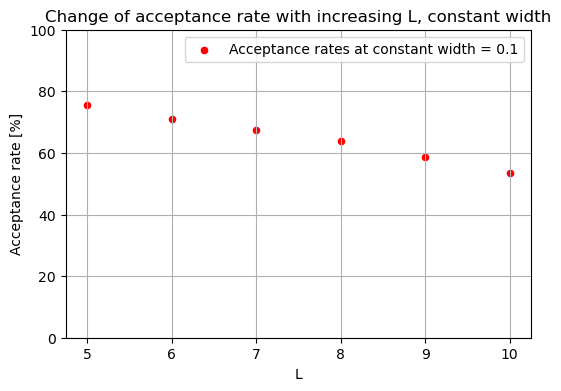

# Question 2: Constant acceptance rate by increasing L and decreasing width

Question 3: The widths are chosen such that the acceptance rate lies between 70 - 80%.

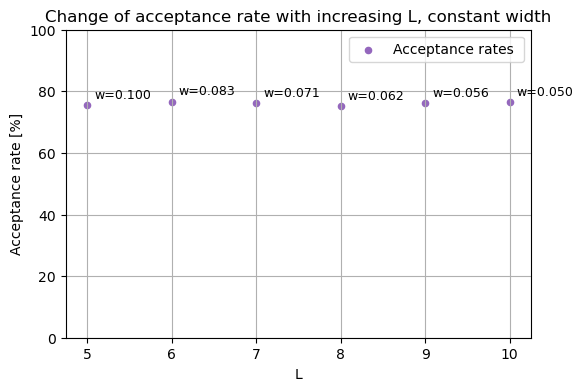

In [1]:
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from metropolis import sample_field

L_vals = list(range(5, 11))
m2 = -0.5
lam = 5.0
rng = np.random.default_rng(seed=42)

acceptance_rates = []
constant_acceptance_rates = []
adapted_widths = []
for L in L_vals:
    phi_field = rng.random(size=(L, L))
    width = 0.1
    adapted_width = 0.5/L
    adapted_widths.append(adapted_width)
    _, acceptance = sample_field(phi_field, 2000, m2, lam, width, rng)
    _, const_acceptance = sample_field(phi_field, 2000, m2, lam, adapted_width, rng)
    acceptance_rates.append(np.mean(acceptance)*100)
    constant_acceptance_rates.append(np.mean(const_acceptance)*100)

display(Markdown("# Question 1: Change of acceptance rate with increasing L, constant width"))
plt.figure(figsize = (6, 4))
plt.scatter(L_vals, acceptance_rates, c= "r", s = 20, label = f"Acceptance rates at constant width = {width}")
plt.title("Change of acceptance rate with increasing L, constant width")
plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.legend()
plt.ylim(0, 100)
plt.grid(True)
plt.show()

display(Markdown("# Question 2: Constant acceptance rate by increasing L and decreasing width"))
display(Markdown("Question 3: The widths are chosen such that the acceptance rate lies between 70 - 80%."))
plt.figure(figsize = (6, 4))
plt.scatter(L_vals, constant_acceptance_rates, c= 'tab:purple', s = 20, label = f"Acceptance rates ")
plt.title("Change of acceptance rate with increasing L, constant width")
plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.legend()
plt.ylim(0, 100)
plt.grid(True)
for L, acc, w in zip(L_vals, constant_acceptance_rates, adapted_widths):
    plt.annotate(f"w={w:.3f}", (L, acc), textcoords="offset points", xytext=(5, 5), ha='left', fontsize=9, color='black')

plt.show()

In [2]:
import numpy as np
from tqdm import tqdm
from physics import sample_observable

L_vals = list(range(5, 11))
m2 = -0.5
lam = 5.0
rng = np.random.default_rng(seed=42)

L_data_dict = {}

for L in tqdm(L_vals, desc="Generating measurements"):
    initial_phi = rng.random(size=(L, L))
    width = 0.5 / L

    measurements, _ = sample_observable(
        initial_phi=initial_phi,
        num_samples=332_640,
        mass2=m2,
        lamb=lam,
        width=width,
        rng=rng
    )

    L_data_dict[f"L{L}"] = np.array(measurements, dtype=np.float32)

#https://numpy.org/doc/stable/reference/generated/numpy.savez.html
np.savez("observable_measurements_L5_to_L10.npz", **L_data_dict) #npz is compressed and efficient for structured data
print("Saved data to 'observable_measurements_L5_to_L10.npz'")

data = np.load("observable_measurements_L5_to_L10.npz")
measurements_L7 = data["L7"]
print(measurements_L7)


Generating measurements: 100%|██████████| 6/6 [03:02<00:00, 30.39s/it]

Saved data to 'observable_measurements_L5_to_L10.npz'
[0.50936556 0.50747263 0.5038006  ... 0.4963899  0.49541327 0.5089073 ]


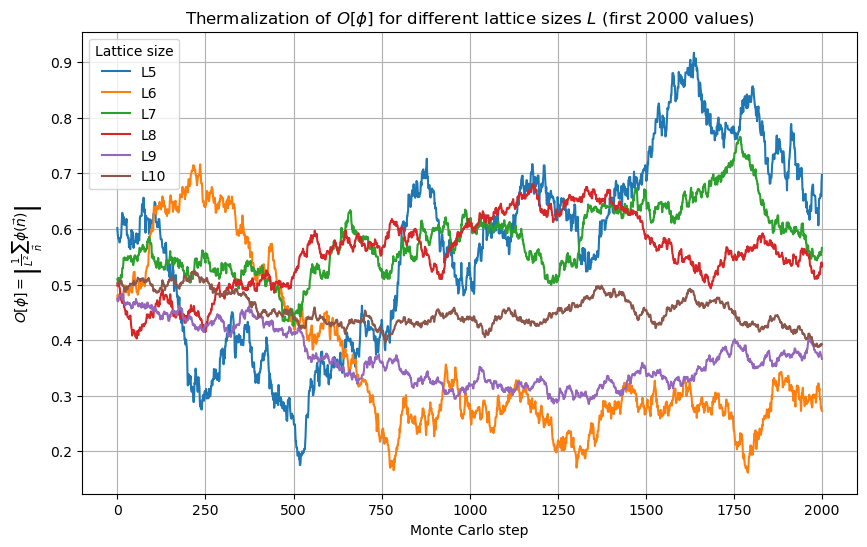

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("observable_measurements_L5_to_L10.npz")

plt.figure(figsize=(10, 6))

for key in sorted(data.keys(), key=lambda x: int(x[1:])):
    measurements = data[key]
    plt.plot(measurements[:2000], label=f"{key}")  #first 2000 values to check for thermalization
plt.title("Thermalization of $O[\\phi]$ for different lattice sizes $L$ (first 2000 values)")
plt.xlabel("Monte Carlo step")
plt.ylabel(r"$O[\phi] = \left| \frac{1}{L^2} \sum_{\vec{n}} \phi(\vec{n}) \right|$")
plt.legend(title="Lattice size")
plt.grid(True)
plt.show()


Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

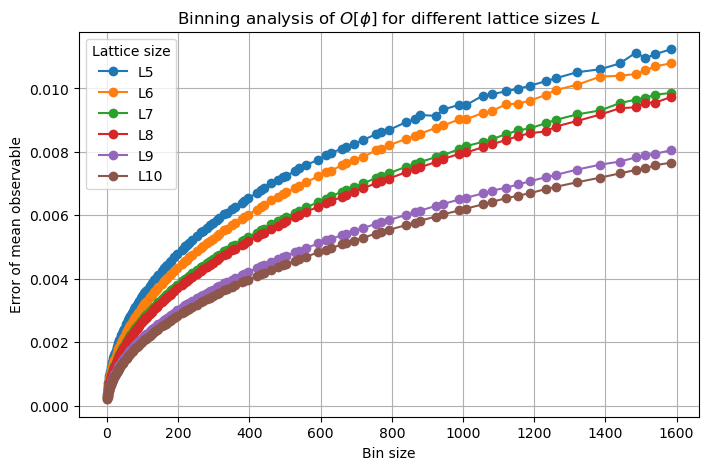

L5: max error = 0.01123
L6: max error = 0.01079
L7: max error = 0.00986
L8: max error = 0.00973
L9: max error = 0.00805
L10: max error = 0.00766


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from physics import apply_binning

data = np.load("observable_measurements_L5_to_L10.npz")

max_errors = {}

plt.figure(figsize=(8, 5))
for key in sorted(data.keys(), key=lambda x: int(x[1:])):
    measurements = data[key]
    bin_sizes, errors = apply_binning(np.array(measurements))

    max_errors[key] = np.max(errors)

    plt.plot(bin_sizes, errors, "o-", label=f"{key}")

plt.title("Binning analysis of $O[\\phi]$ for different lattice sizes $L$")
plt.xlabel("Bin size")
plt.ylabel("Error of mean observable")
plt.legend(title="Lattice size")
plt.grid(True)
plt.show()

for key, err in max_errors.items():
    print(f"{key}: max error = {err:.5f}")


Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/192 [00:00<?, ?it/s]

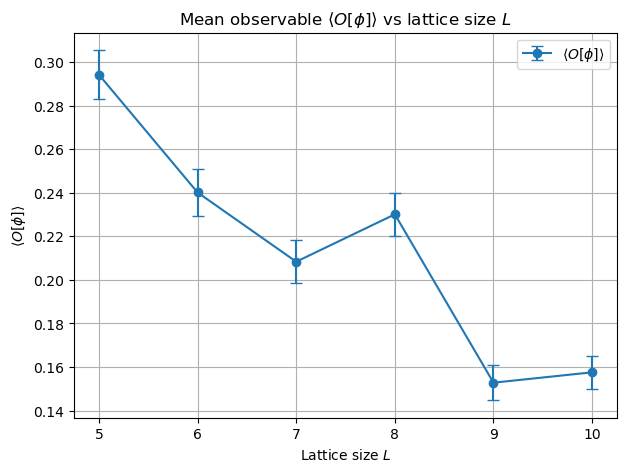

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from physics import apply_binning

data = np.load("observable_measurements_L5_to_L10.npz")

L_vals = sorted([int(key[1:]) for key in data.keys()])
means = []
errors = []

for L in L_vals:
    key = f"L{L}"
    measurements = np.array(data[key])

    mean_val = np.mean(measurements)

    bin_sizes, binned_errors = apply_binning(measurements)
    err_val = np.max(binned_errors) 

    means.append(mean_val)
    errors.append(err_val)

plt.figure(figsize=(7, 5))
plt.errorbar(L_vals, means, yerr=errors, fmt='o-', capsize=4, label=r"$\langle O[\phi] \rangle$")
plt.title(r"Mean observable $\langle O[\phi] \rangle$ vs lattice size $L$")
plt.xlabel("Lattice size $L$")
plt.ylabel(r"$\langle O[\phi] \rangle$")
plt.grid(True)
plt.legend()
plt.show()
